In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay

In [ ]:
data=pd.read_csv("/content/Loan Status Prediction.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


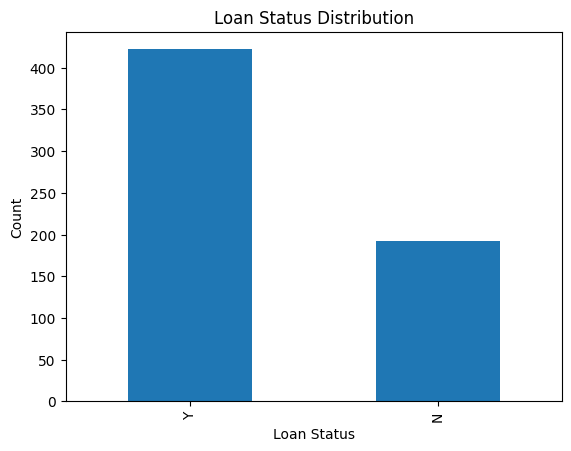

In [ ]:
data['Loan_Status'].value_counts().plot(kind='bar')
plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()


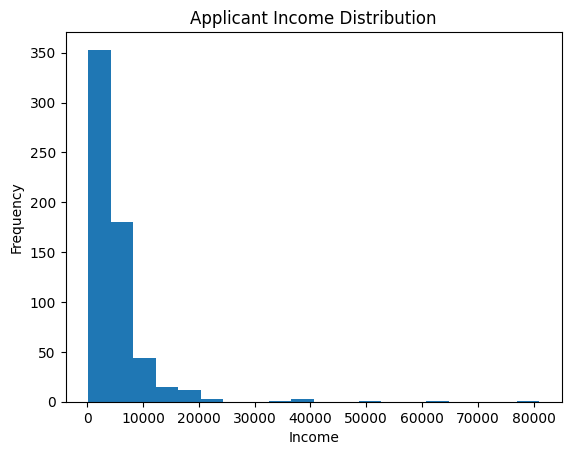

In [ ]:
data['ApplicantIncome'].plot(kind='hist', bins=20)
plt.title("Applicant Income Distribution")
plt.xlabel("Income")
plt.show()

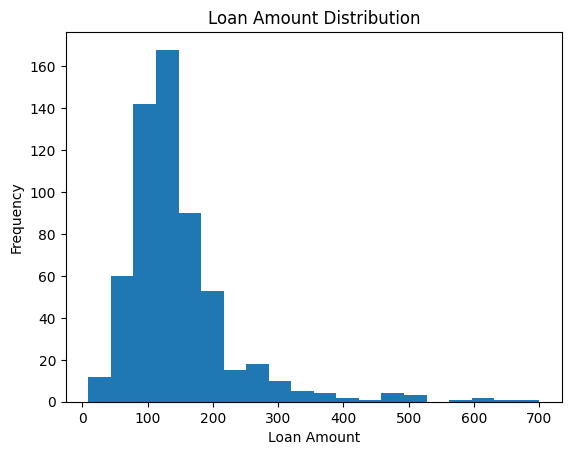

In [ ]:
data['LoanAmount'].plot(kind='hist', bins=20)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.show()

In [ ]:
data.ffill(inplace=True)

In [ ]:
# Encode categorical columns
le = LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [ ]:
# Define features and target
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=2000)
X_train.fillna(X_train.mean(), inplace=True)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred = model.predict(X_test_scaled)

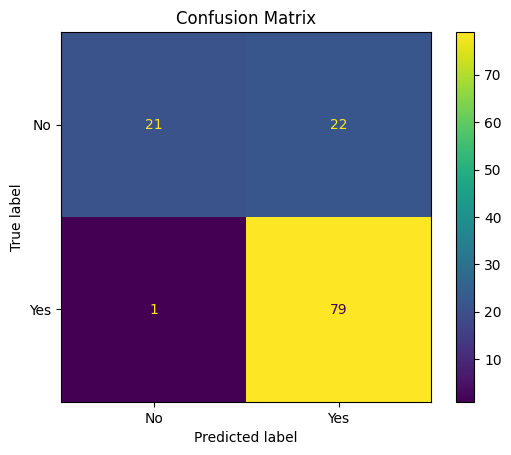

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
disp.plot()

plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 0.81


In [ ]:

# Create input with correct structure
sample_df = pd.DataFrame(columns=X.columns)

# Add one row with default values (0)
sample_df.loc[0] = 0

# Change only required values
sample_df.at[0, 'ApplicantIncome'] = 5000
sample_df.at[0, 'LoanAmount'] = 120
sample_df.at[0, 'Credit_History'] = 1

# Scale the sample data before prediction
sample_df_scaled = scaler.transform(sample_df)

# Predict
prediction = model.predict(sample_df_scaled)

print("Loan Approved ✅" if prediction[0] == 1 else "Loan Not Approved ❌")

Loan Approved ✅
